# Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA

In [2]:
data = np.load("/tscc/lustre/ddn/scratch/kflanagan/RNA_protein_grammar/ml_inputs/PUM1_K562_ENCSR308YNT_PUM2_K562_ENCSR661ICQ.npz")

print(data.files)

['signals', 'chrom', 'start', 'end', 'strand', 'region_id', 'block_number', 'rbp_A', 'rbp_B', 'cell_type']


# Running pytorch

## Data setup

In [3]:
# Extract signal data and region ID. 
signals = data["signals"]
region_ids = data["region_id"]

# Perform a log transform (deals with extremely high outliers).
signals = np.log1p(signals)

# Extract unique regions. 
unique_regions = np.unique(region_ids)

# Shuffle the unique regions for a random training/test split. 
rng = np.random.default_rng(42)
rng.shuffle(unique_regions)

# Make an 80% split. 
split = int(len(unique_regions) * 0.8)
train_regions = unique_regions[:split]
val_regions = unique_regions[split:]

# Perform the masking (the actual mechanism of the split).
train_mask = np.isin(region_ids, train_regions)
val_mask = np.isin(region_ids, val_regions)
train_signals = signals[train_mask]
val_signals = signals[val_mask]

print("Training windows:", train_signals.shape)
print("Validation windows:", val_signals.shape)

Training windows: (10390, 2, 300)
Validation windows: (2565, 2, 300)


In [4]:
print("Minimum:", signals.min())
print("Maximum:", signals.max())
print("Mean:", signals.mean())
print("Median:", np.median(signals))
print("99th percentile:", np.percentile(signals, 99))
print("99.9th percentile:", np.percentile(signals, 99.9))

Minimum: 0.0
Maximum: 8.896174
Mean: 0.35532898
Median: 0.13439058
99th percentile: 2.4833934
99.9th percentile: 5.63817


In [5]:
# Create special data class for machine learning. 
class RBPWindowDataset(Dataset):
    def __init__(self, signals):
        self.signals = torch.tensor(signals, dtype=torch.float32)

    def __len__(self):
        return(len(self.signals))

    def __getitem__(self, idx):
        return(self.signals[idx])


train_dataset = RBPWindowDataset(train_signals)
val_dataset = RBPWindowDataset(val_signals)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

## Model setup

In [6]:
# Set threads equal to number of available CPUs. 
torch.set_num_threads(4)
print("PyTorch threads:", torch.get_num_threads())

class SimpleAutoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()

        # Encoder.
        self.conv1 = nn.Conv1d(in_channels=2, out_channels=16, kernel_size=7, padding=3)
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, padding=2)
        self.pool2 = nn.MaxPool1d(2)

        self.flatten = nn.Flatten()
        self.encoder_fc = nn.Linear(32 * 75, latent_dim)

        # Decoder.
        self.decoder_fc = nn.Linear(latent_dim, 32 * 75)

        self.deconv1 = nn.ConvTranspose1d(
            in_channels=32,
            out_channels=16,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.deconv2 = nn.ConvTranspose1d(
            in_channels=16,
            out_channels=2,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.relu = nn.ReLU()

    def encode(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool1(x)

        x = self.relu(self.conv2(x))
        x = self.pool2(x)

        x = self.flatten(x)
        x = self.encoder_fc(x)

        return(x)

    def decode(self, x):
        x = self.relu(self.decoder_fc(x))

        # Turn the 2400 values back into 32 feature maps × 75 positions.
        x = x.view(-1, 32, 75)

        x = self.relu(self.deconv1(x))
        x = self.deconv2(x)

        return(x)

    def forward(self, x):
        latent = self.encode(x)
        reconstruction = self.decode(latent)

        return(reconstruction)

PyTorch threads: 4


In [7]:
# Set model as autoencode
model = SimpleAutoencoder(latent_dim=64)

# Select mean square error. 
criterion = nn.MSELoss()

# Adam optimizer (what is adam?)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Run model

In [9]:
train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None

num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        reconstruction = model(batch)
        loss = criterion(reconstruction, batch)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    average_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            reconstruction = model(batch)
            loss = criterion(reconstruction, batch)

            total_val_loss += loss.item()

    average_val_loss = total_val_loss / len(val_loader)

    train_losses.append(average_train_loss)
    val_losses.append(average_val_loss)

    if average_val_loss < best_val_loss:
        best_val_loss = average_val_loss
        best_model_state = {
            key: value.cpu().clone()
            for key, value in model.state_dict().items()
        }

    print(
        f"Epoch {epoch + 1}: "
        f"train = {average_train_loss:.6f}, "
        f"validation = {average_val_loss:.6f}"
    )

Epoch 1: train = 0.025315, validation = 0.017152
Epoch 2: train = 0.014206, validation = 0.035158
Epoch 3: train = 0.014150, validation = 0.009470
Epoch 4: train = 0.008462, validation = 0.007646
Epoch 5: train = 0.006884, validation = 0.006488
Epoch 6: train = 0.005876, validation = 0.005511
Epoch 7: train = 0.006114, validation = 0.007951
Epoch 8: train = 0.005497, validation = 0.004512
Epoch 9: train = 0.004257, validation = 0.004208
Epoch 10: train = 0.003923, validation = 0.003806
Epoch 11: train = 0.003626, validation = 0.003843
Epoch 12: train = 0.003547, validation = 0.004122
Epoch 13: train = 0.003416, validation = 0.003273
Epoch 14: train = 0.003233, validation = 0.003531
Epoch 15: train = 0.003230, validation = 0.003129
Epoch 16: train = 0.003054, validation = 0.004521
Epoch 17: train = 0.003748, validation = 0.003302
Epoch 18: train = 0.002813, validation = 0.003196
Epoch 19: train = 0.002958, validation = 0.002895
Epoch 20: train = 0.002578, validation = 0.002719


In [10]:
# Loads best model, not just last model. 
model.load_state_dict(best_model_state)

print(f"Best validation loss: {best_val_loss:.6f}")

Best validation loss: 0.002719


## Diagnostics

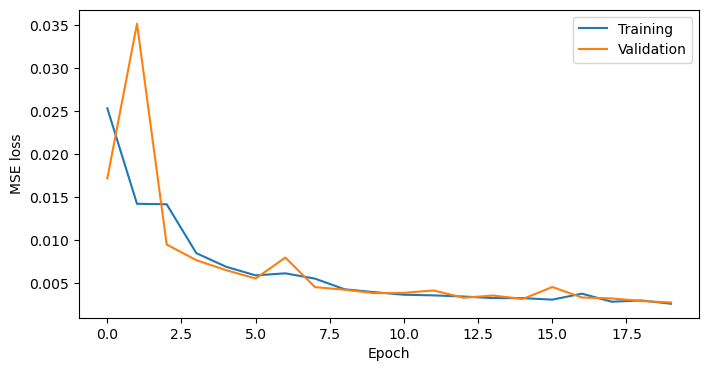

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Training")
plt.plot(val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.show()

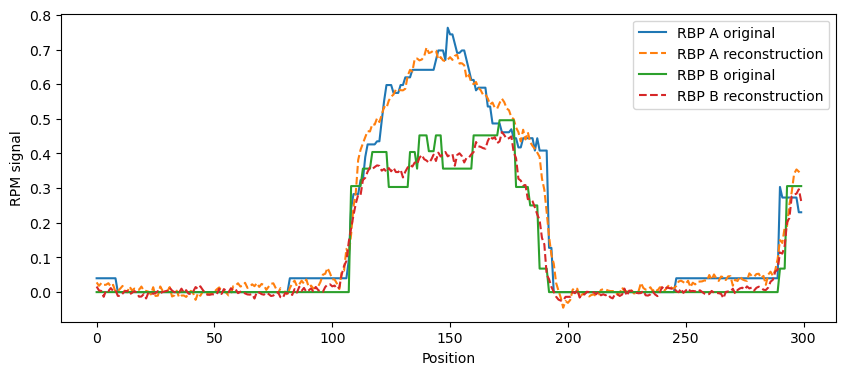

In [12]:
batch = next(iter(train_loader))
reconstruction = model(batch)

i = 0

original = batch[i].detach().numpy()
reconstructed = reconstruction[i].detach().numpy()

plt.figure(figsize=(10, 4))

plt.plot(original[0], label="RBP A original")
plt.plot(reconstructed[0], label="RBP A reconstruction", linestyle="--")

plt.plot(original[1], label="RBP B original")
plt.plot(reconstructed[1], label="RBP B reconstruction", linestyle="--")

plt.xlabel("Position")
plt.ylabel("RPM signal")
plt.legend()
plt.show()

## Clustering/PCA

In [13]:
model.eval()

latent_vectors = []
validation_signals = []

with torch.no_grad():
    for batch in val_loader:
        latent = model.encode(batch)

        latent_vectors.append(latent.numpy())
        validation_signals.append(batch.numpy())

latent_vectors = np.concatenate(latent_vectors, axis=0)
validation_signals = np.concatenate(validation_signals, axis=0)

print("Validation signals:", validation_signals.shape)
print("Latent vectors:", latent_vectors.shape)

Validation signals: (2565, 2, 300)
Latent vectors: (2565, 64)


In [14]:
print("Latent minimum:", latent_vectors.min())
print("Latent maximum:", latent_vectors.max())
print("Latent mean:", latent_vectors.mean())
print("Latent std:", latent_vectors.std())

Latent minimum: -14.535135
Latent maximum: 16.009819
Latent mean: -0.019105999
Latent std: 0.7474454


In [16]:
pca = PCA(n_components=2)
latent_pca = pca.fit_transform(latent_vectors)

print("Variance explained:",
      pca.explained_variance_ratio_)

Variance explained: [0.3730492  0.22854914]


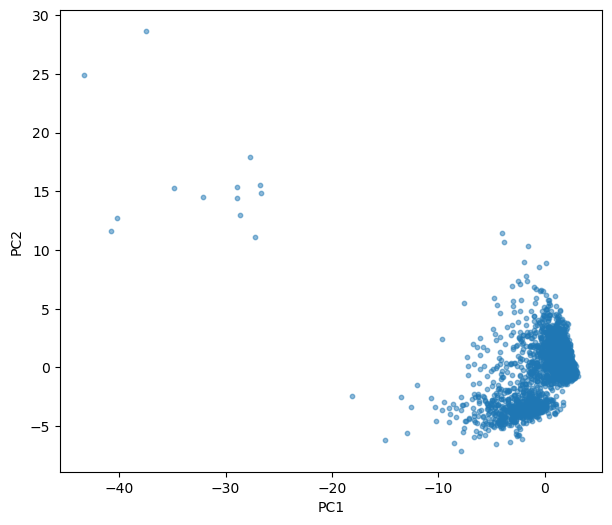

In [17]:
plt.figure(figsize=(7, 6))
plt.scatter(latent_pca[:, 0], latent_pca[:, 1], s=10, alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()